In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from brokenaxes import brokenaxes
from PIL import Image
import pandas as pd
import numpy as np
import pickle
import os


In [ ]:

color_groups = {
    'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
    'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
    'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
}
new_names = {
    'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
    'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
    'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
}

def draw_curves_grid_simple(records, image_dir=None, show_images=False,
                             n_rows=4, n_cols=4, save_path=None, stylef=None):
    n_patients = len(records)
    y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
    y_max = 1

    # grades = data_to_plot['diagnosis_amd_grade']
    # visit_number = data_to_plot['visit_number']
    # marker_x = None
    # marker_panel_idx_local = marker_panel_idx

    # if any(g in [10, 11, 12] for g in grades):
    #     if first_conversion_idx is None:
    #         fc_idx = next((i for i, g in enumerate(grades) if g >= 10), None)
    #         if fc_idx is not None and fc_idx > 0:
    #             marker_panel_idx_local = fc_idx - 1
    #             marker_x = fc_idx + 1
    #     else:
    #         marker_x = first_conversion_idx
            

    with plt.style.context(stylef):
        # ── Build ONE figure + ONE grid layout, regardless of show_images ──
        if show_images:
            fig = plt.figure(figsize=((n_cols + 1) * 3, n_rows * 2.5))
            outer_gs = gridspec.GridSpec(n_rows, n_cols + 1, figure=fig,
                                          width_ratios=[1] * n_cols + [1.3],
                                          wspace=0.2, hspace=0.6)
        else:
            fig = plt.figure(figsize=(n_cols * 3, n_rows * 2.5))
            outer_gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                                          wspace=0.3, hspace=0.6)

        for p, rec in enumerate(records):
            row, col_in_row = divmod(p, n_cols)
            cell = outer_gs[row, col_in_row]

            bax = brokenaxes(
                xlims=((-0.1, 0.002), (0.9, 5.1)),
                hspace=0.01, d=0.005, tilt=45,
                subplot_spec=cell,
                fig=fig
            )

            for model, curve in rec['curves'].items():
                bax.plot(range(1, len(curve) + 1), curve,
                          label=new_names.get(model, model),
                          color=color_groups.get(model), linewidth=1.5)

            title = (f"ID {rec['patient_id']}\n"
                      f"freeze={rec['freeze_encoder']} n={rec['train_size']} evt={rec['has_event']}")
            bax.set_title(title, fontsize=8)
            bax.set_ylim(y_min, y_max)
            bax.axs[1].set_yticks([0, 0.5, 1])
            bax.axs[0].set_xticks([])
            bax.axs[1].set_xticks([1, 2, 3, 4, 5])

            # restore visible left spine/ticks on the baseline mini-axis
            bax.axs[0].spines['left'].set_visible(True)
            bax.axs[0].tick_params(left=True, labelleft=True)

            for a in bax.axs:
                a.tick_params(axis='both', labelsize=7)

            if col_in_row == 0:
                bax.set_ylabel('S(t)', fontsize=9)
            if row == n_rows - 1:
                bax.set_xlabel('Year', fontsize=9)

            # ── image block for this row, drawn once after last curve column ──
            if show_images and col_in_row == n_cols - 1:
                img_gs = gridspec.GridSpecFromSubplotSpec(
                    2, 2, subplot_spec=outer_gs[row, n_cols], wspace=0.05, hspace=0.05
                )
                row_records = records[row * n_cols: row * n_cols + n_cols]
                for k, r in enumerate(row_records):
                    img_ax = fig.add_subplot(img_gs[k // 2, k % 2])
                    img_path = os.path.join(image_dir, f"R_{r['image_path']}")
                    img_ax.imshow(Image.open(img_path))
                    img_ax.axis('off')

        # ── One shared legend, built independently of any specific axis ──
        handles = [plt.Line2D([0], [0], color=color_groups[m], linewidth=1.5) for m in color_groups]
        labels = [new_names[m] for m in color_groups]
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.4, 0.98),
                   ncol=4, fontsize=9)

        plt.tight_layout()
        # fig.subplots_adjust(bottom=0.15)

    if save_path is not None:
        plt.savefig(f'{save_path}/surv_curves_grid2.pdf', bbox_inches='tight')
    plt.show()

In [4]:

def get_model_curves(df, model_name, img_to_plot, CHKPT_DIR):
    print(df.head(3))
    print(df.columns)
    row = df[(df['model']==model_name)]
    print('img_to_plot', img_to_plot)
    exp_best = row['best_result'].values[0]
    full_path = os.path.join(CHKPT_DIR, exp_best)
    exp_df = pd.read_csv(os.path.join(full_path, 'test_survival_curves.csv' ))
    image_curve = img_to_plot
    print('image_curve', image_curve)
    image_curve = image_curve.split('/')[-1]
    print('image_curve', image_curve)

    h = exp_df[exp_df['image_name'] == image_curve ]
    print('h', h)
    s = h['survival_curve'].values[0].strip().strip('[]')
    print('s', s)
    surv_curv = [float(x) for x in s.split()]
    print('surv_curv',surv_curv)
    return surv_curv

def pick_same_index_across_lists(row):
    # print('--------------------------------------')
    # print()
    # print(row)
    # print('--------------------------------------')
    # print()
    list_lengths = [len(v) for v in row if isinstance(v, list)]
    print('list lengths', list_lengths)
    if not list_lengths:
        return row

    n = list_lengths[0]
    chosen_idx = n -1 #rng.integers(0, n)

    return row.apply(lambda v: [v[chosen_idx]] if isinstance(v, list) else v)
def get_all_curves(all_images_to_plot0, model_list, dfl_ssl, CHKPT_DIR):
    print(all_images_to_plot0)
    all_images_to_plot0 = all_images_to_plot0['image_path']
    curves_dict = {}
    for img_to_plot in all_images_to_plot0:
        for m in model_list:
            surv_curv = get_model_curves(dfl_ssl, m, img_to_plot, CHKPT_DIR)
            if m not in curves_dict:
                curves_dict[m]=[]
            curves_dict[m].append(surv_curv)
    print('len of curves_dict', curves_dict)
    return curves_dict
def plot_one_image_curve(or_df, test, freeze_encoder = 1, train_size = 500, 
                         num_images = 2, has_event = True, CHKPT_DIR = '', num0 = None):

    dfl = or_df[(or_df['freeze_encoder'] == freeze_encoder) & (or_df['survival_head'] == 'mlp') & (or_df['train_size'] == train_size)]
    dfl_ssl = dfl.groupby(['weights_path']).agg(list)

    dfl_ssl['model'] = dfl_ssl['summary'].apply(lambda x: x[0])
    model_list = sorted(list(dfl_ssl['model'].unique()))
    # print('model list',model_list)
    dfl_ssl['best_idx'] = dfl_ssl['test/ibs'].apply(lambda x: np.argmin(np.array(x)) )

    dfl_ssl['best_result'] = dfl_ssl.apply(lambda row: row['Name'][row['best_idx']], axis=1)
    dfl_ssl['best_result'].head()

    test['converter'] = test['diagnosis_amd_grade'].apply(lambda x: x in [10, 11, 12])
    test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
    test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
    test_grp['n_img'].value_counts()

    test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)
    test_grp['has_event'].value_counts()

    # print(test_grp.columns)

    sample_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == has_event)].reset_index(drop = False)
    # print('sample', sample_[['patient_id', 'visit_number', 'converter', 'has_event', 'diagnosis_amd_grade']])
    if num0 is None:
        num0 = random.randint(0,(len(sample_)-1))
    print('num0 is', num0)

    all_images_to_plot =  sample_.loc[num0, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number", "converter"]]
    # print('all_images_to_plot', all_images_to_plot)

    all_images_to_plot = pick_same_index_across_lists(all_images_to_plot)

    print('--------------------------------------')
    print()
    print(all_images_to_plot)
    print('--------------------------------------')
    print()
    curves_dict ={}

    curves_dict = get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)
    return curves_dict, all_images_to_plot

In [5]:
log_dir = '/home/berens/bep973/ifeoma_home/leverage-data/log_dir'
CLEANED_FILE = 'areds_new_results_cleaned_03_06_26_split_id_11042026.csv'
CHKPT_DIR= chkpt_dir ='/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/survival_on_embedding/checkpoints/npj_areds_to_save'
root_dir = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/areds/datasets'
stylef = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/survival_on_embedding/utils/berenslab.mplstyle'
RESULTS_DIR = '/home/berens/bep973/ifeoma_home/leverage-data/results'
img_dir =    '/home/berens/bep973/ifeoma_home/data/AREDS_macula/AREDS_macula'

csv_dir = os.path.dirname(root_dir)
print(csv_dir)
split_id = 11042026

/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/areds


In [6]:
or_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
print(or_df.shape)
or_df.head(2)

(1120, 71)


,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [7]:
metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()


/tmp/ipykernel_2325862/1714322262.py:1: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1001,1001_left,1001_left_RS_04,4,left,F2,RS,51685_04_F2_LE_RS.jpg,51685/51685_04_F2_LE_RS.jpg,3.0,...,4.0,N,N,6.0,N,74.4,1001_left,1001_left_4,16,0
1,1001,1001_left,1001_left_LS_06,6,left,F2,LS,51685_06_F2_LE_LS.jpg,51685/51685_06_F2_LE_LS.jpg,3.0,...,4.0,N,N,6.0,N,75.4,1001_left,1001_left_6,14,0
2,1001,1001_left,1001_left_LS_08,8,left,F2,LS,51685_08_F2_LE_LS.jpg,51685/51685_08_F2_LE_LS.jpg,2.0,...,4.0,N,N,6.0,N,76.4,1001_left,1001_left_8,12,0
3,1001,1001_left,1001_left_RS_10,10,left,F2,RS,51685_10_F2_LE_RS.jpg,51685/51685_10_F2_LE_RS.jpg,4.0,...,4.0,N,N,6.0,N,77.5,1001_left,1001_left_10,10,0
4,1001,1001_left,1001_left_LS_14,14,left,F2,LS,51685_14_F2_LE_LS.jpg,51685/51685_14_F2_LE_LS.jpg,6.0,...,4.0,N,N,6.0,N,80.1,1001_left,1001_left_14,6,0


In [8]:
patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(root_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test

,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11137,G617,G617_right,G617_right_RS_08,8,right,F2,RS,53179_08_F2_RE_RS.jpg,53179/53179_08_F2_RE_RS.jpg,5.0,...,4.0,N,N,6.0,Y,72.8,G617_right,G617_right_8,8,0
11138,G617,G617_right,G617_right_LS_10,10,right,F2,LS,53179_10_F2_RE_LS.jpg,53179/53179_10_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,73.8,G617_right,G617_right_10,6,0
11139,G617,G617_right,G617_right_LS_12,12,right,F2,LS,53179_12_F2_RE_LS.jpg,53179/53179_12_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,75.0,G617_right,G617_right_12,4,0
11140,G617,G617_right,G617_right_LS_14,14,right,F2,LS,53179_14_F2_RE_LS.jpg,53179/53179_14_F2_RE_LS.jpg,8.0,...,4.0,N,N,6.0,Y,76.0,G617_right,G617_right_14,2,0


In [9]:
info_dict = [
        {'freeze_encoder': 1, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 1, 'train_size': 30000, 'has_event': True},

        {'freeze_encoder': 0, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 0, 'train_size': 30000, 'has_event': True},

            ]


In [10]:
import random
# num0 = random.choice(range(0, test.shape[0]))
# num0

In [11]:
records = []

for i, vals in enumerate(info_dict):
    freeze_encoder = vals['freeze_encoder']
    train_size = vals['train_size']
    has_event = vals['has_event']
    dict1, img_to_plot = plot_one_image_curve(
        or_df, test, freeze_encoder=freeze_encoder,
        train_size=train_size, num_images=2, has_event=has_event,
        CHKPT_DIR=CHKPT_DIR, num0=None
    )

    records.append({
        'freeze_encoder': freeze_encoder,
        'train_size': train_size,
        'has_event': has_event,
        'patient_id': img_to_plot['patient_id'][0] if isinstance(img_to_plot['patient_id'], list) else img_to_plot['patient_id'],
        'image_path': img_to_plot['image_path'][0] if isinstance(img_to_plot['image_path'], list) else img_to_plot['image_path'],
        'diagnosis_amd_grade': img_to_plot['diagnosis_amd_grade'][0] if isinstance(img_to_plot['diagnosis_amd_grade'], list) else img_to_plot['diagnosis_amd_grade'],
        'visit_number': img_to_plot['visit_number'][0] if isinstance(img_to_plot['visit_number'], list) else img_to_plot['visit_number'],

        # 'image_path': img_to_plot['image_path'],
        # 'diagnosis_amd_grade': img_to_plot['diagnosis_amd_grade'],
        # 'visit_number': img_to_plot['visit_number'],
        'curves': {model: curve[0] for model, curve in dict1.items()},  # unwrap the outer list
    })

num0 is 7
list lengths [5, 5, 5, 5, 5]
--------------------------------------

image_path             [2737/2737_10_LE_F2_LS.jpg]
diagnosis_amd_grade                         [11.0]
patient_id                                  [2737]
visit_number                                  [10]
converter                                   [True]
Name: 7, dtype: object
--------------------------------------

image_path             [2737/2737_10_LE_F2_LS.jpg]
diagnosis_amd_grade                         [11.0]
patient_id                                  [2737]
visit_number                                  [10]
converter                                   [True]
Name: 7, dtype: object
                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_500_mlp_2026-06-11_04-4...   
dino_nako     [testrun_False_FE_True_500_mlp_2026-06-09_03-1...   
nako_mae      [testrun_False_FE_True_500_mlp_2026-06-10_2

In [ ]:

RESULTS_DIR = 'results'
draw_curves_grid_simple(records, image_dir=img_dir, show_images=True,
                         save_path=RESULTS_DIR, stylef=stylef)

/tmp/ipykernel_2325862/3282783176.py:103: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(f'{save_path}/surv_curves_grid2.pdf', bbox_inches='tight')


In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

color_groups = {
    'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
    'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
    'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
}
new_names = {
    'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
    'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
    'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
}
full_data = {'image_path': [], 'diagnosis_amd_grade': [], 'ID': [], 'visit_number': []}
full_curves_dict = {}

for i, vals in enumerate(info_dict):  # however you get the list of individuals in `test`
    freeze_encoder = vals['freeze_encoder']
    train_size = vals['train_size']
    has_event = vals['has_event']

    dict1, img_to_plot = plot_one_image_curve(
        or_df, test, freeze_encoder=freeze_encoder, 
        train_size=train_size, num_images=2, has_event=has_event,
        CHKPT_DIR=CHKPT_DIR, num0=0 #i
        # + whatever argument selects this specific patient, e.g. patient_id=patient_id
    )

    # Accumulate per-visit data
    patient_id = img_to_plot['patient_id']
    full_data['image_path'].extend(img_to_plot['image_path'])
    full_data['diagnosis_amd_grade'].extend(img_to_plot['diagnosis_amd_grade'])
    full_data['visit_number'].extend(img_to_plot['visit_number'])
    # full_data['ID'].extend([patient_id] * len(img_to_plot['image_path']))
    full_data['ID'].extend(patient_id)


    # Accumulate per-model curves
    for model, curve in dict1.items():
        full_curves_dict.setdefault(model, []).extend(curve)



num0 is 0
--------------------------------------

image_path             [56634/56634_12_F2_LE_RS.jpg]
diagnosis_amd_grade                           [11.0]
patient_id                                    [1234]
visit_number                                    [12]
converter                                     [True]
Name: 0, dtype: object
--------------------------------------

image_path             [56634/56634_12_F2_LE_RS.jpg]
diagnosis_amd_grade                           [11.0]
patient_id                                    [1234]
visit_number                                    [12]
converter                                     [True]
Name: 0, dtype: object
                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_500_mlp_2026-06-11_04-4...   
dino_nako     [testrun_False_FE_True_500_mlp_2026-06-09_03-1...   
nako_mae      [testrun_False_FE_True_500_mlp_2026-06-10_21-4...   

In [ ]:
from curve_utils import draw_curves_grid

in standalone
grades [11, 8, 11, 8, 11, 8, 11, 8]
fc_idx 0
first conversion index  marker is None


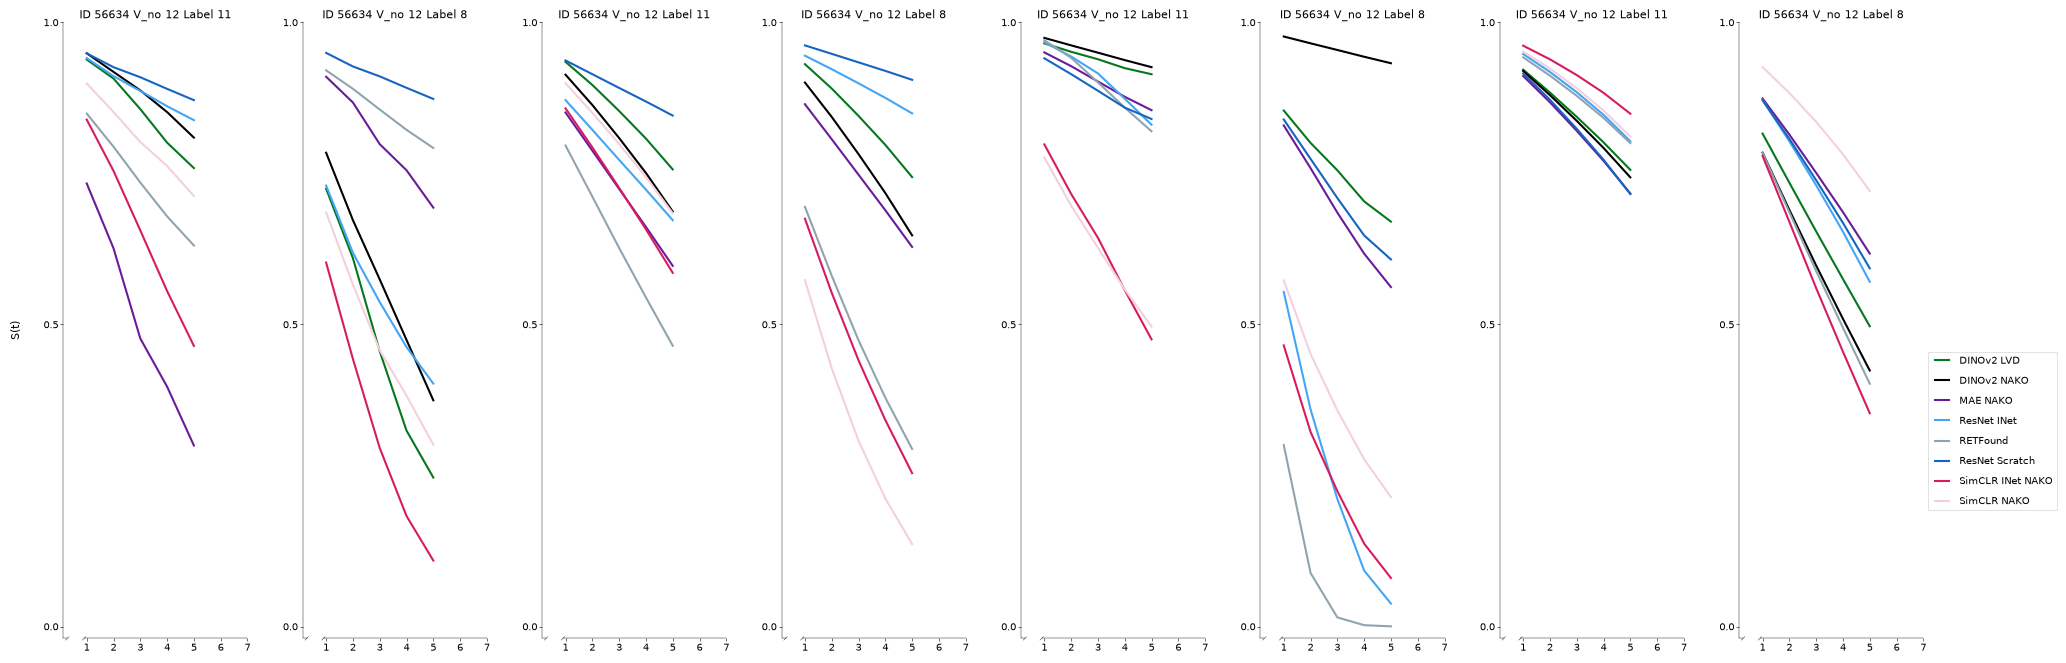

In [18]:
draw_curves_grid(full_data, full_curves_dict, 
                  save_path=RESULTS_DIR, stylef=stylef)